In [2]:
import os, sys, importlib

repo_root = "/Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels"

src_dir = os.path.join(repo_root, "src")

if src_dir in sys.path:
    sys.path.remove(src_dir)
sys.path.insert(0, src_dir)

print("sys.path[0]:", sys.path[0])

sys.modules.pop("gnm", None)

import gnm
import gnm.defaults as defaults

print("gnm module:", gnm.__file__)
print("defaults module:", defaults.__file__)

sys.path[0]: /Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/src


AttributeError: `np.float_` was removed in the NumPy 2.0 release. Use `np.float64` instead.

In [2]:
import gnm
import gnm.defaults as defaults
print("gnm module:", gnm.__file__)
print("defaults module:", defaults.__file__)

gnm module: /Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/src/gnm/__init__.py
defaults module: /Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/src/gnm/defaults/__init__.py


In [ ]:
from gnm.fitting import experiment_saving
from gnm.fitting.experiment_dataclasses import Experiment
from gnm import defaults, fitting, generative_rules, weight_criteria
import torch

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [21]:
distance_matrix = defaults.get_distance_matrix(device=DEVICE)

In [22]:
import numpy as np

file_path = "/Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/weighted_connectivity.npy"
weighted_connectivity = np.load(file_path)

print(weighted_connectivity.shape)

(90, 90, 446)


<Axes: >

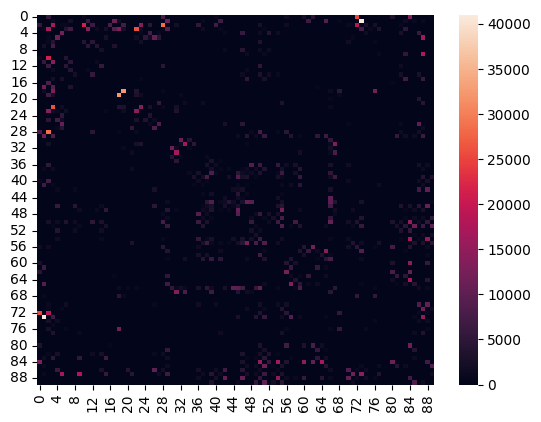

In [23]:
import seaborn as sns

sns.heatmap(weighted_connectivity[:,:,0])

In [24]:
print("Original shape:", weighted_connectivity.shape)

# (90, 90, 446) → (446, 90, 90)
all_networks_np = np.transpose(weighted_connectivity, (2, 0, 1))
print("After transpose:", all_networks_np.shape)   # (446, 90, 90)

# 0 stays 0, anything > 0 becomes 1
all_binary_networks_np = (all_networks_np > 0).astype(np.float32)

print("Binary shape:", all_binary_networks_np.shape)  # (446, 90, 90)

all_binary_networks = torch.tensor(all_binary_networks_np, device=DEVICE)

S, N, _ = all_binary_networks.shape
print("Num subjects:", S)  #  446
print("Num nodes:", N)     # 90


Original shape: (90, 90, 446)
After transpose: (446, 90, 90)
Binary shape: (446, 90, 90)
Num subjects: 446
Num nodes: 90


In [30]:
num_connections = int(all_binary_networks.sum().item() / 446 )
print(f"The binary consensus network contains {num_connections} connections.")

The binary consensus network contains 800 connections.


In [75]:
num_simulations = 5 #when i run the seed, match the number of simulations -- do not redefine below
file_path = "/Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/seed.npy"
seed = np.load(file_path)
seed_new = np.broadcast_to(seed, (num_simulations,seed.shape[0], seed.shape[1]))
tensor_seed = torch.tensor(seed_new, device=DEVICE)

In [76]:
print(seed_new)
print(tensor_seed)

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
  

In [77]:
eta_values = torch.Tensor(torch.linspace(-5, 1, 3))
print(f'Eta Values: {eta_values}')
gamma_values = torch.Tensor(torch.linspace(0, 2, 3))
print(gamma_values)
print(f'Num connections: {num_connections}')

Eta Values: tensor([-5., -2.,  1.])
tensor([0., 1., 2.])
Num connections: 800


In [78]:
binary_sweep_parameters = fitting.BinarySweepParameters(
    eta = eta_values,
    gamma = gamma_values,
    lambdah = torch.Tensor([0.0]),
    distance_relationship_type = ["powerlaw"],
    preferential_relationship_type = ["powerlaw"],
    heterochronicity_relationship_type = ["powerlaw"],
    generative_rule = [generative_rules.MatchingIndex()],
    num_iterations = [num_connections],
)

#add the seeding...
sweep_config = fitting.SweepConfig(
    binary_sweep_parameters = binary_sweep_parameters,
    # weighted_sweep_parameters = weighted_sweep_parameters,
    num_simulations = num_simulations,
    distance_matrix = [distance_matrix]    
)


In [79]:
from gnm.fitting.experiment_saving import ExperimentEvaluation

from gnm import evaluation

criteria = [ evaluation.ClusteringKS(), evaluation.DegreeKS(), evaluation.EdgeLengthKS(distance_matrix), evaluation.BetweennessKS() ]
energy = evaluation.MaxCriteria( criteria )
binary_evaluations = [energy]
#weighted_evaluations = [ evaluation.WeightedNodeStrengthKS(normalise=True), evaluation.WeightedClusteringKS() ]

experiments = fitting.perform_sweep(sweep_config=sweep_config, 
                                binary_evaluations=binary_evaluations, 
                                real_binary_matrices= all_binary_networks,
                                # weighted_evaluations=weighted_evaluations,
                                save_model = False,
                                save_run_history = False,
                                verbose=True
)

Using device: cpu for GNM simulations


Configuration Iterations: 100%|██████████| 9/9 [01:18<00:00,  8.69s/it]

Average time per run: 8.61 seconds
Total time for sweep: 77.50 seconds


In [80]:
print(experiments)

[Experiment(run_config=RunConfig(binary_parameters=BinaryGenerativeParameters(eta=tensor(-5.), gamma=tensor(0.), lambdah=tensor(0.), distance_relationship_type='powerlaw', preferential_relationship_type='powerlaw', heterochronicity_relationship_type='powerlaw', generative_rule=<gnm.generative_rules.generative_rules.MatchingIndex object at 0x319b38f10>, num_iterations=800, prob_offset=1e-06, binary_updates_per_iteration=1), num_simulations=5, seed_adjacency_matrix=None, distance_matrix=tensor([[0.0000, 0.5303, 0.3052,  ..., 0.7891, 0.5180, 0.7986],
        [0.5303, 0.0000, 0.4924,  ..., 0.5788, 0.7938, 0.5220],
        [0.3052, 0.4924, 0.0000,  ..., 0.6583, 0.6355, 0.7755],
        ...,
        [0.7891, 0.5788, 0.6583,  ..., 0.0000, 0.6861, 0.3155],
        [0.5180, 0.7938, 0.6355,  ..., 0.6861, 0.0000, 0.6856],
        [0.7986, 0.5220, 0.7755,  ..., 0.3155, 0.6856, 0.0000]]), weighted_parameters=None, seed_weight_matrix=None, heterochronous_matrix=None), evaluation_results=EvaluationRe

In [1]:
eval = ExperimentEvaluation('./test_experiment_evals')
eval.save_experiments(experiments)
eval.get_dataframe_of_results() 

NameError: name 'ExperimentEvaluation' is not defined

In [ ]:
#eval.list_experiment_parameters()

Experiment Parameters:
   - eta
   - gamma
   - lambdah
   - distance_relationship_type
   - preferential_relationship_type
   - heterochronicity_relationship_type
   - generative_rule
   - num_iterations
   - prob_offset
   - binary_updates_per_iteration
   - n_participants
   - mean_of_max_ks_per_connectome
   - std_of_max_ks_per_connectome
   - per_connectome_binary_evals


dict_keys(['eta', 'gamma', 'lambdah', 'distance_relationship_type', 'preferential_relationship_type', 'heterochronicity_relationship_type', 'generative_rule', 'num_iterations', 'prob_offset', 'binary_updates_per_iteration', 'n_participants', 'mean_of_max_ks_per_connectome', 'std_of_max_ks_per_connectome', 'per_connectome_binary_evals'])

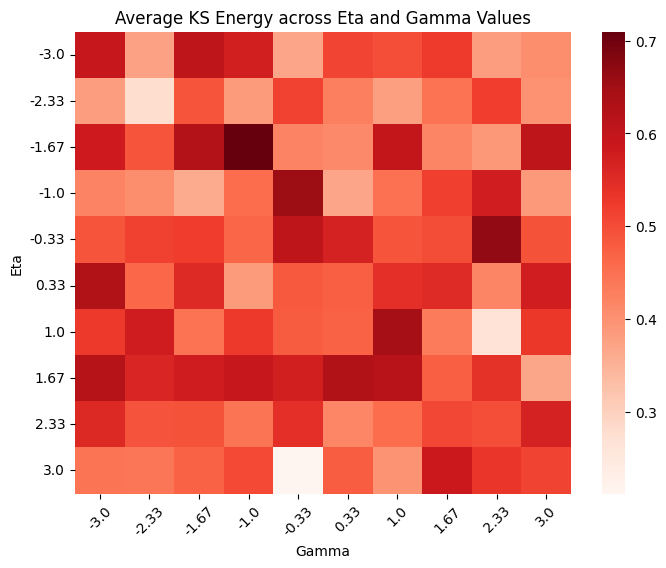

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# every combination of eta and gamma, for 10 connectomes
eta_values = np.linspace(-3, 3, 10)
gamma_values = np.linspace(-3, 3, 10)

# generate a synthetic ks results dataframe
results_df = pd.DataFrame({
    'connectome_index': np.tile(np.arange(10), 100),
    'eta': np.repeat(eta_values, 100),
    'gamma': np.tile(gamma_values, 100),
    'mean_ks': np.random.uniform(0, 1, 1000),
    'std_ks': np.random.uniform(0, 1, 1000)
})

plt.figure(figsize=(8,6))

# scatter eta and gamma points, coloured by energy
etas = results_df['eta'].unique()
gammas = results_df['gamma'].unique()

avg_energies = results_df.groupby(['eta', 'gamma'])['mean_ks'].mean().unstack()

sns.heatmap(avg_energies, xticklabels=np.round(gammas, 2), yticklabels=np.round(etas, 2), cmap='Reds', cbar=True)
plt.title('Average KS Energy across Eta and Gamma Values')
plt.xlabel('Gamma')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.ylabel('Eta')
plt.show()